# Bildklassifikation für Qualitätskontrolle im Agrarbereich
## MobileNetV2 (Feature Extraction) + XGBoost (Klassifikation)

**Architektur:**
```
Bild → MobileNetV2 (eingefroren, kein Top) → 1280-dim Feature-Vektor → XGBoost → Klasse
```


## 1. Imports & Konfiguration

In [31]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import xgboost as xgb

from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

print("TensorFlow Version:", tf.__version__)
print("XGBoost Version:   ", xgb.__version__)
print("GPU verfügbar:     ", tf.config.list_physical_devices("GPU"))

TensorFlow Version: 2.21.0
XGBoost Version:    3.2.0
GPU verfügbar:      []


In [ ]:
# ── Konfiguration ──────────────────────────────────────────────────────────────
DATA_DIR   = Path(r"c:/Users/Hendrik/Downloads/archive/Fruit And Vegetable Diseases Dataset/Apple_Data_sing")
IMG_SIZE   = (224, 224)   # MobileNetV2 erwartet 224x224
BATCH_SIZE = 32
SEED       = 42

# XGBoost-Hyperparameter
XGB_PARAMS = dict(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=SEED,
    n_jobs=-1
)

FEATURE_PATH = "features.npz"         # gecachte Features (spart Zeit bei erneutem Lauf)
MODEL_PATH   = "mobilenet_xgboost.json"


SyntaxError: invalid syntax. Perhaps you forgot a comma? (3842619189.py, line 9)

## 2. Dataset laden & aufteilen (70 / 15 / 15)

Identisch zum ursprünglichen MobileNetV2-Notebook.

In [ ]:
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

class_names = train_ds_raw.class_names
num_classes = len(class_names)

# Temp-Split in Val und Test aufteilen
temp_batches = temp_ds.cardinality().numpy()
val_batches  = temp_batches // 2
val_ds_raw   = temp_ds.take(val_batches)
test_ds_raw  = temp_ds.skip(val_batches)

print("Klassen:            ", class_names)
print("Training Batches:   ", train_ds_raw.cardinality().numpy())
print("Validation Batches: ", val_ds_raw.cardinality().numpy())
print("Test Batches:       ", test_ds_raw.cardinality().numpy())


Found 5363 files belonging to 2 classes.
Using 3755 files for training.
Found 5363 files belonging to 2 classes.
Using 1608 files for validation.
Klassen:             ['Apple__Healthy', 'Apple__Rotten']
Training Batches:    118
Validation Batches:  25
Test Batches:        26


## 3. Data Augmentation

Nur für Training – Val/Test erhalten **keine** Augmentation.  
Identisch zum ursprünglichen Notebook.

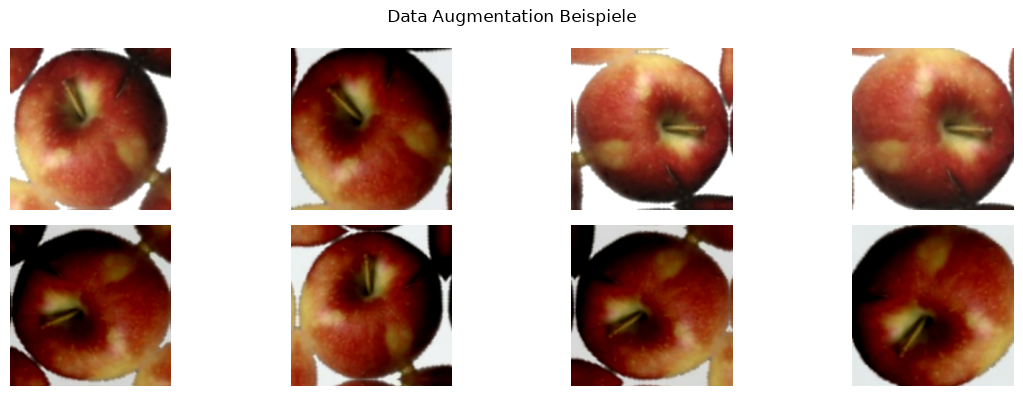

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.1),
], name="augmentation")

AUTOTUNE = tf.data.AUTOTUNE

# Augmentation-Vorschau
sample_images, _ = next(iter(train_ds_raw))
plt.figure(figsize=(12, 4))
for i in range(8):
    ax = plt.subplot(2, 4, i + 1)
    aug_img = data_augmentation(tf.expand_dims(sample_images[0], 0), training=True)
    plt.imshow(aug_img[0].numpy().astype("uint8"))
    plt.axis("off")
plt.suptitle("Data Augmentation Beispiele")
plt.tight_layout()
plt.show()


In [ ]:
# Pipeline optimieren — Augmentation nur auf Training anwenden
train_ds = train_ds_raw.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE,
).prefetch(AUTOTUNE)

val_ds  = val_ds_raw.prefetch(AUTOTUNE)
test_ds = test_ds_raw.prefetch(AUTOTUNE)


## 4. MobileNetV2 als Feature Extractor aufbauen

Der Dense-Head (256 Neuronen + Softmax) wird **entfernt**.  
Stattdessen gibt `GlobalAveragePooling2D` einen **1280-dimensionalen Feature-Vektor** pro Bild aus.  
Dieser Vektor ist der Input für XGBoost.

```
MobileNetV2 (eingefroren) → GlobalAveragePooling2D → (batch, 1280)
```

In [ ]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,       # letzten Dense-Layer weglassen
    weights="imagenet",
)
base_model.trainable = False  # eingefroren — nur Feature Extraktion

feature_extractor = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(scale=1./127.5, offset=-1.0, name="mobilenet_preprocess"),
    base_model,
    layers.GlobalAveragePooling2D(),   # → (batch, 1280)
], name="MobileNetV2_FeatureExtractor")

feature_extractor.summary()


Model: "MobileNetV2_FeatureExtractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_preprocess            │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

## 5. Features extrahieren

Alle Bilder werden einmalig durch den Feature Extractor geschickt.  
Die Ergebnisse werden in `features.npz` gespeichert – bei erneutem Ausführen wird der Cache geladen.

In [ ]:
def extract_features(dataset, model, split_name=""):
    """Schickt alle Batches durch den Feature Extractor und sammelt Labels."""
    features, labels = [], []
    total = dataset.cardinality().numpy()
    for i, (images, lbls) in enumerate(dataset):
        feats = model(images, training=False)
        features.append(feats.numpy())
        labels.append(lbls.numpy())
        if (i + 1) % 10 == 0:
            print(f"  {split_name}: {i+1}/{total} Batches", end="\r")
    print()
    return np.concatenate(features), np.concatenate(labels)


In [ ]:
if Path(FEATURE_PATH).exists():
    print("Features aus Cache laden...")
    cache  = np.load(FEATURE_PATH)
    X_train, y_train = cache["X_train"], cache["y_train"]
    X_val,   y_val   = cache["X_val"],   cache["y_val"]
    X_test,  y_test  = cache["X_test"],  cache["y_test"]
else:
    print("Features extrahieren (dauert einige Minuten)...")
    X_train, y_train = extract_features(train_ds, feature_extractor, "Train")
    X_val,   y_val   = extract_features(val_ds,   feature_extractor, "Val")
    X_test,  y_test  = extract_features(test_ds,  feature_extractor, "Test")

    np.savez(FEATURE_PATH,
             X_train=X_train, y_train=y_train,
             X_val=X_val,     y_val=y_val,
             X_test=X_test,   y_test=y_test)
    print(f"Features gespeichert → {FEATURE_PATH}")

print(f"Train Features: {X_train.shape}")
print(f"Val   Features: {X_val.shape}")
print(f"Test  Features: {X_test.shape}")


Features aus Cache laden...
Train Features: (3755, 1280)
Val   Features: (800, 1280)
Test  Features: (808, 1280)


## 6. XGBoost trainieren

XGBoost erhält die 1280-dimensionalen Feature-Vektoren aus MobileNetV2 als Input.

In [ ]:
clf = xgb.XGBClassifier(**XGB_PARAMS)

clf.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,
)

# Modell speichern
clf.save_model(MODEL_PATH)
print(f"\nModell gespeichert → {MODEL_PATH}")


[0]	validation_0-logloss:0.63197
[50]	validation_0-logloss:0.11300
[100]	validation_0-logloss:0.08077
[150]	validation_0-logloss:0.07024
[200]	validation_0-logloss:0.06233
[250]	validation_0-logloss:0.06056
[299]	validation_0-logloss:0.05839

Modell gespeichert → mobilenet_xgboost.json


## 7. Evaluation auf dem Test-Set

In [ ]:
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)

test_acc = np.mean(y_pred == y_test)
print(f"Test Accuracy: {test_acc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=class_names))


Test Accuracy: 0.9653

                precision    recall  f1-score   support

Apple__Healthy       0.95      0.97      0.96       345
 Apple__Rotten       0.98      0.96      0.97       463

      accuracy                           0.97       808
     macro avg       0.96      0.97      0.96       808
  weighted avg       0.97      0.97      0.97       808



## 8. Confusion Matrix

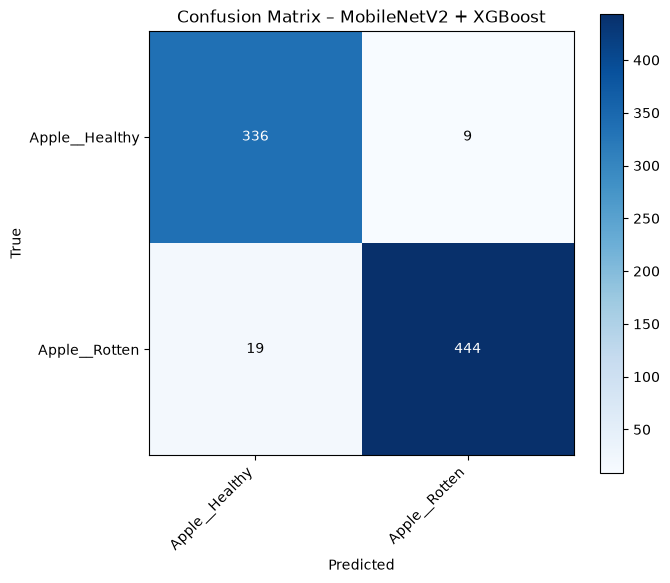

In [ ]:
cm  = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im)
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticks(range(num_classes))
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix – MobileNetV2 + XGBoost")
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.savefig("confusion_matrix_xgb.png", dpi=150)
plt.show()


## 9. XGBoost Feature Importance

Zeigt, welche der 1280 MobileNetV2-Aktivierungen XGBoost am stärksten für die Klassifikation nutzt.

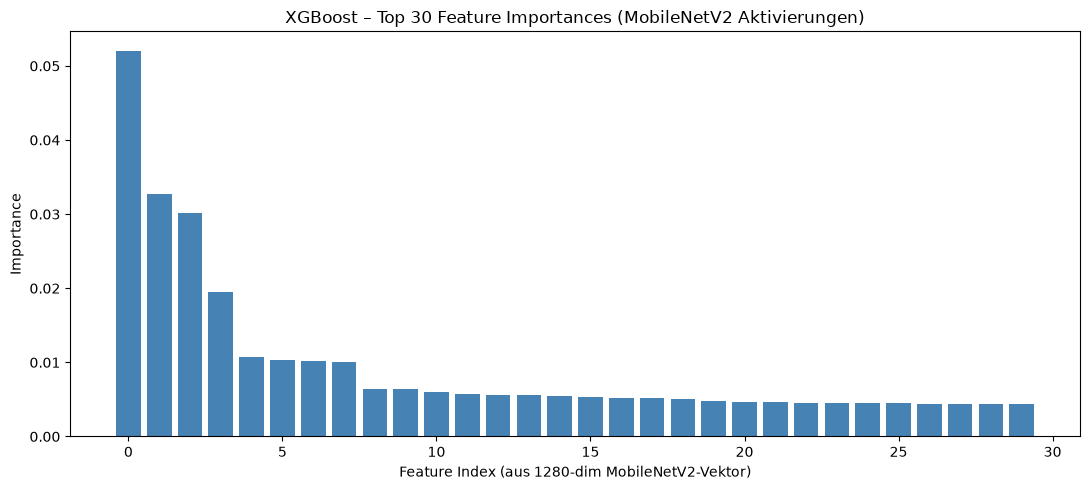

In [ ]:
importance = clf.feature_importances_
top_idx    = np.argsort(importance)[-30:][::-1]

plt.figure(figsize=(11, 5))
plt.bar(range(30), importance[top_idx], color="steelblue")
plt.title("XGBoost – Top 30 Feature Importances (MobileNetV2 Aktivierungen)")
plt.xlabel("Feature Index (aus 1280-dim MobileNetV2-Vektor)")
plt.ylabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance_xgb.png", dpi=150)
plt.show()


## 10. Einzelbild-Inferenz (für Produktivsystem)

Identische Schnittstelle wie im ursprünglichen MobileNetV2-Notebook.

In [ ]:
def predict_single_image(image_path: str):
    """Klassifiziert ein einzelnes Bild mit MobileNetV2 + XGBoost."""
    img       = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)   # Batch-Dimension hinzufügen

    features      = feature_extractor(img_array, training=False).numpy()
    pred_label    = int(clf.predict(features)[0])
    probabilities = clf.predict_proba(features)[0]

    predicted_class = class_names[pred_label]
    confidence      = float(probabilities[pred_label])

    print(f"Klasse:      {predicted_class}")
    print(f"Konfidenz:   {confidence:.2%}")
    print(f"Alle Scores: { {c: f'{p:.2%}' for c, p in zip(class_names, probabilities)} }")

    return predicted_class, confidence

# Beispielaufruf:
# predicted_class, conf = predict_single_image("pfad/zum/bild.jpg")


---
## Nächste Schritte


